In [139]:
import numpy as np
from sklearn.datasets import fetch_california_housing
import matplotlib.pyplot as plt

In [140]:
import warnings
warnings.filterwarnings("ignore")

In [141]:
housing = fetch_california_housing()  # 加载加州房价数据集

In [142]:
X = housing.data[:, 0].reshape(-1, 1)  # 选择MedInc作为唯一特征,并且将一维数据转换为二维特征矩阵

In [143]:
y = housing.target  # 房价中位数作为目标值

In [144]:
X = X[y < 5]  # 删除目标值大于等于 5 的样本，减少房价上限截断对回归模型的影响
y = y[y < 5]  # 使用相同条件过滤目标值，保证 X 和 y 的样本一一对应

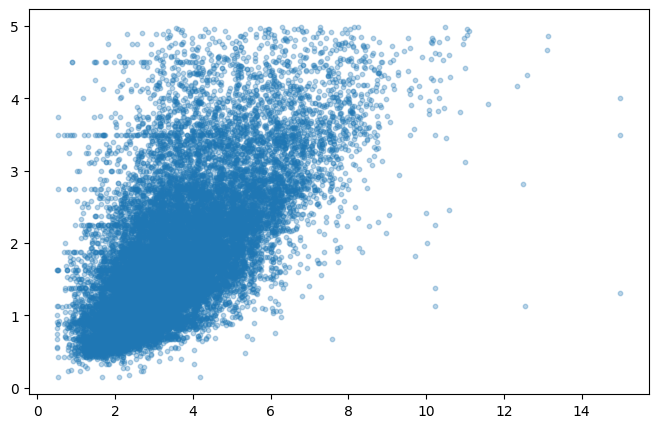

In [145]:
plt.figure(figsize=(8, 5))
plt.scatter(X, y, alpha=0.3, s=10)
plt.show()

In [146]:
from sklearn.model_selection import train_test_split

In [147]:
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.7, random_state=233, shuffle=True)

## sklearn实现一元线性回归

In [148]:
from sklearn.linear_model import LinearRegression  # 导入线性回归模型

In [149]:
lin_reg = LinearRegression()  # 创建线性回归模型

In [150]:
result = lin_reg.fit(X_train.reshape(-1, 1), y_train);  # 使用训练集训练模型，reshape(-1, 1) 将特征转换为二维特征矩阵

In [151]:
y_predict = lin_reg.predict(X_test.reshape(-1, 1))  # 使用测试集进行预测

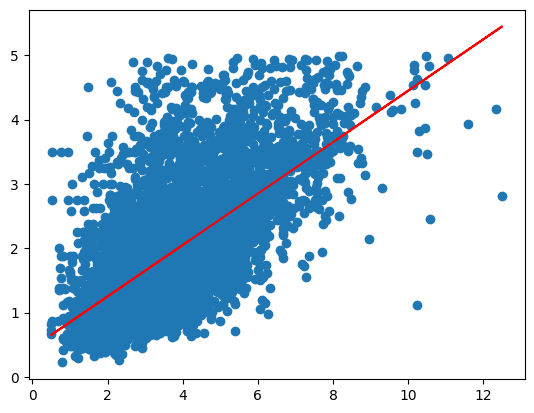

In [152]:
plt.scatter(X_test, y_test)
plt.plot(X_test, y_predict, c="r")
plt.show()

## MSE

In [153]:
y_real = y_test  # 保存真实值

In [154]:
mse = np.sum((y_real - y_predict) ** 2) / len(y_test)  # 手动计算均方误差 MSE
mse

np.float64(0.5514196830605563)

In [155]:
from sklearn.metrics import mean_squared_error  # 导入MSE评价函数
mse = mean_squared_error(y_real, y_predict)  # 使用sklearn计算MSE
mse

0.5514196830605563

## RMSE

In [156]:
rmse = np.sqrt(mse)  # 对MSE开平方，计算RMSE
rmse

np.float64(0.7425763819706067)

In [157]:
from sklearn.metrics import root_mean_squared_error  # 导入RMSE函数
rmse = root_mean_squared_error(y_real, y_predict)  # 计算RMSE
rmse

0.7425763819706067

## MAE

In [158]:
mae = np.sum(np.abs(y_real - y_predict)) / len(y_test)  # 手动计算平均绝对误差（MAE）
mae

np.float64(0.5690444067353739)

In [159]:
from sklearn.metrics import mean_absolute_error  # 导入计算平均绝对误差的函数
mae = mean_absolute_error(y_real, y_predict)  # 使用 sklearn 计算 MAE
mae

0.5690444067353739

## R方

In [160]:
r2 = 1 - (np.sum((y_real - y_predict) ** 2) / np.sum((y_real - np.mean(y_real)) ** 2))  # 手动计算 R²
r2

np.float64(0.4225085623778292)

In [161]:
1 - mse / np.var(y_real)  # 使用 MSE 计算 R²

np.float64(0.4225085623778292)

In [162]:
from sklearn.metrics import r2_score  # 导入 R² 计算函数
r2_score(y_real, y_predict)  # 计算 R²

0.4225085623778292

In [163]:
result.score(X_test, y_test)

0.4225085623778292